# EfficientNet-B0 Classification 

## Purpose of this Notebook
The objective of this phase is to train a Google **EfficientNet-B0** Convolutional Neural Network (CNN). Unlike U-Net (which measures physical size), EfficientNet acts as our "Texture Model." Its primary job is to analyze the microscopic textures, chromatin patterns, and color densities within the cropped cells to output mathematical class probabilities.
In the final pipeline, the Deep Model Probabilities generated by this model will be fused with the U-Net morphological features to feed our final XGBoost Meta-Learner.


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import random_split

### Data Transformation and Validation Split
EfficientNet architectures require standardized input dimensions to perform optimal feature extraction. We apply a series of transformations to resize all cell crops to `224x224` pixels and normalize their color channels using standard ImageNet mean and standard deviation metrics.
To ensure robust evaluation and prevent data leakage, we mathematically split the `ImageFolder` dataset into an 80% Training subset and a 20% Validation subset. 


In [ ]:
# 1. Image Transformations (EfficientNet works with 224x224 images, so we resize them)
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(
                mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]
            ) # Standard color correction
])

In [6]:
# 2. Load the Dataset automatically using PyTorch's amazing ImageFolder!
cnn_path = r"..\processed_data\cnn_dataset"
dataset  = datasets.ImageFolder(root=cnn_path, transform=transform)

In [7]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [8]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Loaded {len(dataset)} images!")
print(f"Training on {train_size} images, Validating on {val_size} images.")
print(f"Classes: {dataset.classes}")

Loaded 4049 images!
Training on 3239 images, Validating on 810 images.
Classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


### 2. Transfer Learning Architecture
Training a deep CNN from scratch is computationally expensive and highly prone to overfitting on localized medical datasets. To bypass this, we utilize **Transfer Learning**.
We instantiate an EfficientNet-B0 model pre-trained on ImageNet. Because the original architecture was designed to output 1000 arbitrary classes, we truncate the final classification layer and replace it with a newly initialized `nn.Linear` layer specifically tailored to our 5 cervical cell morphological classes.

In [9]:
# 3. Create the EfficientNet Model
print("Building EfficientNet-B0 Model...")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# The original EfficientNet was built to guess 1000 different objects (dogs, cars, etc.)
# We must replace its final 'guessing' layer to only output our 5 SIPaKMeD classes!
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)

Building EfficientNet-B0 Model...


In [10]:
# 4. Turn on your NVIDIA RTX 4050 GPU!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


### Model Training & Early Stopping Optimization
We initialize the `Adam` optimizer alongside a `CrossEntropyLoss` criterion and assign the tensor calculations to the GPU.

**Hyperparameter Optimization:**
* `epochs = 50`: Extended training allowance to guarantee convergence.
* `patience = 10`: An **Early Stopping** mechanism. Due to the sheer power of the pre-trained EfficientNet weights, the model is highly susceptible to rapid overfitting. The algorithm strictly monitors the Validation Loss and prematurely halts training the moment generalization ceases, ensuring the absolute optimal weights are preserved.

In [11]:
# 5. Math for learning
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# epochs = 50           
# patience = 10         
# best_val_loss = float('inf')
# patience_counter = 0

# train_losses = []
# val_losses = []
# train_accuracies = [] 
# val_accuracies = []   

# for epoch in range(epochs):
#     model.train()
#     running_train_loss = 0.0
#     correct_train = 0
#     total_train = 0
    
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         predictions = model(images)
#         loss = criterion(predictions, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_train_loss += loss.item()
        
#         _, winning_class = torch.max(predictions, 1)
#         correct_train += (winning_class == labels).sum().item()
#         total_train += labels.size(0)
    
#     avg_train_loss = running_train_loss / len(train_loader)
#     avg_train_acc = (correct_train / total_train) * 100 
    
#     train_losses.append(avg_train_loss)
#     train_accuracies.append(avg_train_acc)
    
#     model.eval() 
#     running_val_loss = 0.0
#     correct_val = 0
#     total_val = 0
    
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images, labels = images.to(device), labels.to(device)
#             predictions = model(images)
#             loss = criterion(predictions, labels)
#             running_val_loss += loss.item()
            
#             # Calculate Validation Accuracy
#             _, winning_class = torch.max(predictions, 1)
#             correct_val += (winning_class == labels).sum().item()
#             total_val += labels.size(0)
            
#     avg_val_loss = running_val_loss / len(val_loader)
#     avg_val_acc = (correct_val / total_val) * 100 
    
#     val_losses.append(avg_val_loss)
#     val_accuracies.append(avg_val_acc)
    
#     print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.2f}% | Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.2f}%")
    
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         patience_counter = 0 
        
#         save_dir = r"..\trained_models\cnn"
#         os.makedirs(save_dir, exist_ok=True)
#         torch.save(model.state_dict(), os.path.join(save_dir, 'efficientnet_sipakmed.pth'))
#     else:
#         patience_counter += 1
#         if patience_counter >= patience:
#             print(f"\nEarly stopping triggered! The AI started overfitting after {epoch+1} epochs.")
#             break 

# print("\nTraining Complete! The best EfficientNet weights have been saved.")


Epoch [1/50] - Train Loss: 0.4764, Acc: 83.48% | Val Loss: 0.1855, Acc: 93.46%
Epoch [2/50] - Train Loss: 0.2640, Acc: 91.26% | Val Loss: 0.4440, Acc: 87.65%
Epoch [3/50] - Train Loss: 0.2114, Acc: 92.99% | Val Loss: 0.1254, Acc: 94.81%
Epoch [4/50] - Train Loss: 0.1454, Acc: 95.03% | Val Loss: 0.1475, Acc: 94.44%
Epoch [5/50] - Train Loss: 0.1501, Acc: 94.91% | Val Loss: 0.1548, Acc: 95.06%
Epoch [6/50] - Train Loss: 0.1028, Acc: 96.05% | Val Loss: 0.1926, Acc: 94.32%
Epoch [7/50] - Train Loss: 0.1173, Acc: 95.99% | Val Loss: 0.0823, Acc: 97.04%
Epoch [8/50] - Train Loss: 0.0783, Acc: 97.41% | Val Loss: 0.1559, Acc: 95.56%
Epoch [9/50] - Train Loss: 0.0921, Acc: 96.57% | Val Loss: 0.1429, Acc: 95.19%
Epoch [10/50] - Train Loss: 0.0783, Acc: 97.41% | Val Loss: 0.1918, Acc: 93.83%
Epoch [11/50] - Train Loss: 0.0878, Acc: 96.97% | Val Loss: 0.0759, Acc: 97.41%
Epoch [12/50] - Train Loss: 0.0616, Acc: 97.93% | Val Loss: 0.0790, Acc: 97.04%
Epoch [13/50] - Train Loss: 0.0706, Acc: 97.72% |

### Evaluating Convergence Metrics
Following training, we visualize the learning curves by plotting the epoch-by-epoch loss and accuracy metrics. This graph provides empirical proof of the Early Stopping algorithm in action, clearly demonstrating the exact epoch where optimal convergence was achieved before overfitting began.

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import torch.nn.functional as F

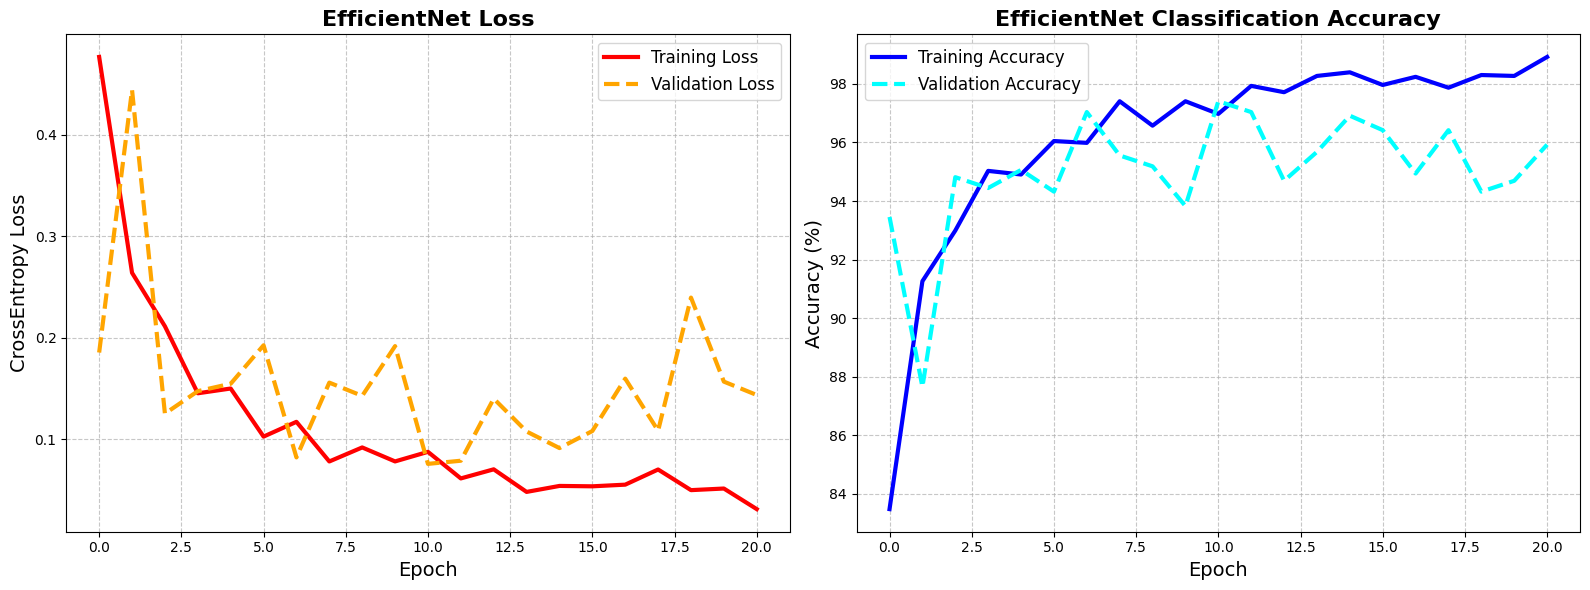

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: LOSS ---
axes[0].plot(train_losses, label='Training Loss', color='red', linewidth=3)
axes[0].plot(val_losses, label='Validation Loss', color='orange', linewidth=3, linestyle='--')
axes[0].set_title('EfficientNet Loss', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('CrossEntropy Loss', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=12)

# --- GRAPH 2: ACCURACY ---
axes[1].plot(train_accuracies, label='Training Accuracy', color='blue', linewidth=3)
axes[1].plot(val_accuracies, label='Validation Accuracy', color='cyan', linewidth=3, linestyle='--')
axes[1].set_title('EfficientNet Classification Accuracy', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Accuracy (%)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

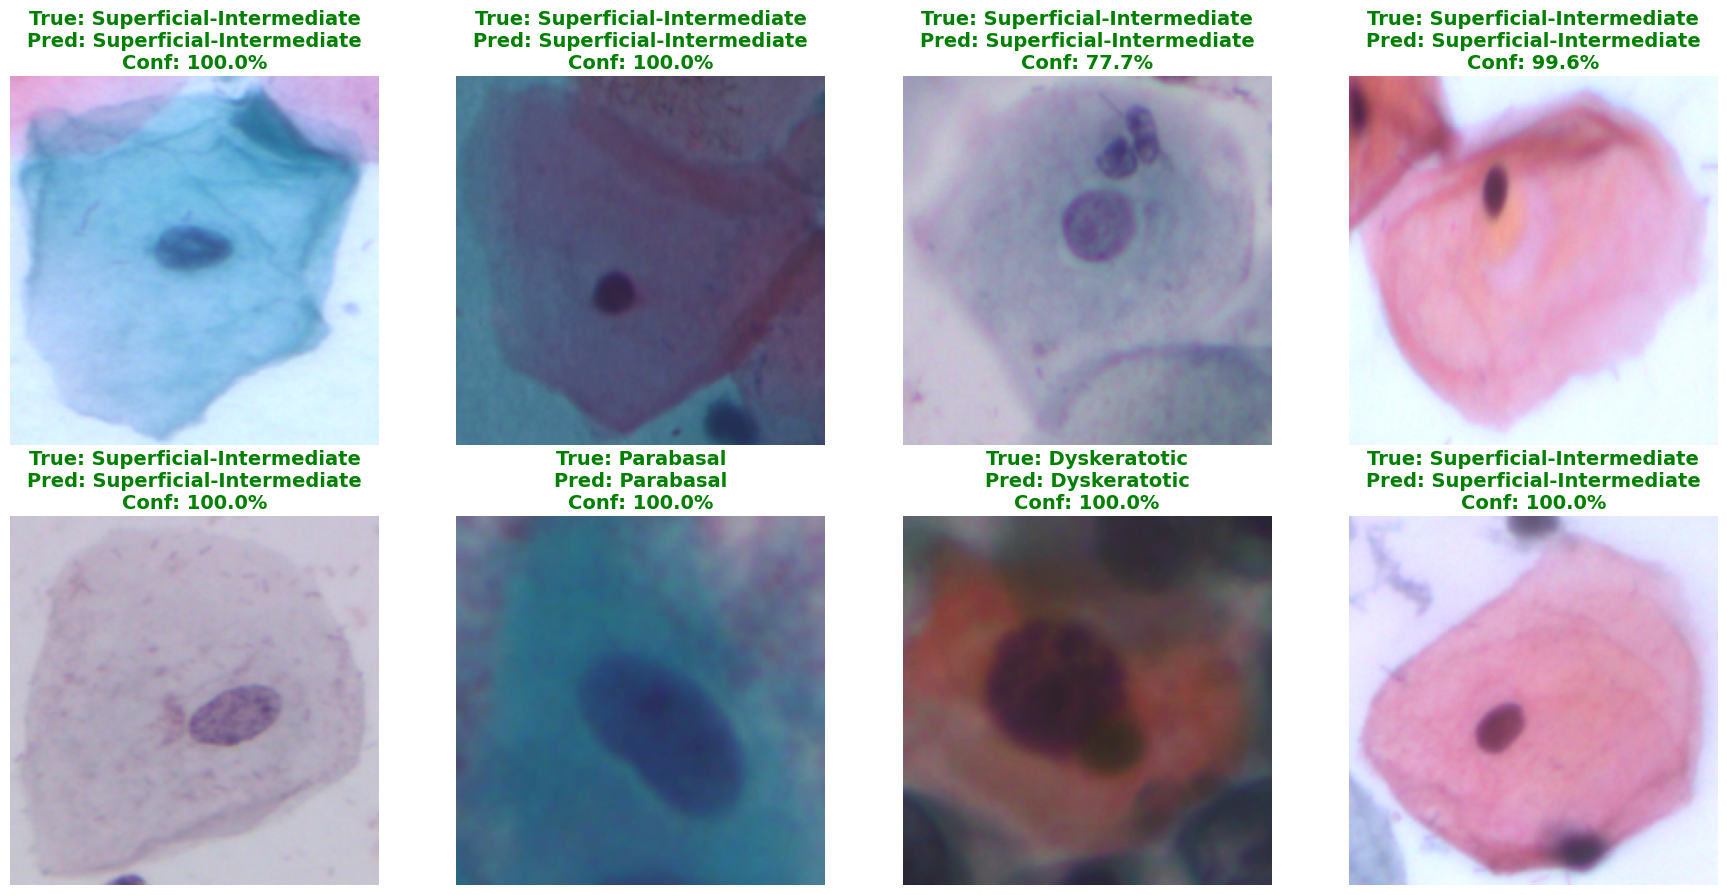

In [ ]:
model.eval()
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    predictions = model(images)
    probabilities = F.softmax(predictions, dim=1) 
    confidence, predicted_classes = torch.max(probabilities, 1)

images = images.cpu().numpy().transpose(0, 2, 3, 1) 
labels = labels.cpu().numpy()
predicted_classes = predicted_classes.cpu().numpy()
confidence = confidence.cpu().numpy() * 100

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
images = np.clip(images * std + mean, 0, 1)

class_names = dataset.classes 

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(8):
    # Draw the cell image
    axes[i].imshow(images[i])
    axes[i].axis('off')
    
    # Clean up the names (remove the 'im_')
    true_name = class_names[labels[i]].replace('im_', '')
    pred_name = class_names[predicted_classes[i]].replace('im_', '')
    
    # Make the text Green if correct, Red if wrong
    color = "green" if true_name == pred_name else "red"
    
    title = f"True: {true_name}\nPred: {pred_name}\nConf: {confidence[i]:.1f}%"
    axes[i].set_title(title, color=color, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
